# Training and evaluation results

This notebook scans the JSON summaries each time it runs,
so new models, checkpoints, variants, and runs appear
without manually copying numbers into the notebook.

Data conventions:

- Data source : JSON files under `results/`
- The summary table uses the **latest available checkpoint per arm**,
  not the best checkpoint, to avoid implicit checkpoint selection.
- Older AIME24 summaries do not contain `arm` or `eval_config`;
  their identities are recovered from the directory layout and are marked as schema 0.
- Scores are shown on a 0–1 scale in tables and as percentages in plots.


In [1]:
"""Interactive results overview for Zed's Python REPL.

After editing this file, synchronize it with the shareable notebook:

    .venv/bin/jupytext --sync results/viz/results_overview.py
"""

from __future__ import annotations

import json
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.ticker import PercentFormatter

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
plt.style.use("seaborn-v0_8-whitegrid")


def find_repo_root(start: Path | None = None) -> Path:
    """Work when launched from the repo root, results/viz, or a parent directory."""
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "results").is_dir() and (candidate / "train").is_dir():
            return candidate
    raise FileNotFoundError("Could not find a repository root containing results/ and train/")


ROOT = find_repo_root()
RESULTS = ROOT / "results"
print(f"Repository: {ROOT}")
print(f"Results:    {RESULTS}")

Repository: /home/ujan/self-distill
Results:    /home/ujan/self-distill/results


In [2]:
#
# For the initial overview, checkpoint curves are more informative than a single bar
# per method: they show training dynamics and make clear
# which checkpoint is being compared. Each panel uses the exact base-model
# evaluation as a horizontal reference. Variants and repeated runs remain separate series.
#

In [3]:
AIME_DIR = RESULTS / "aime24"

def read_json(path: Path) -> dict:
    with path.open() as handle:
        return json.load(handle)


def checkpoint_number(step: str | None) -> int | None:
    if not step:
        return None
    match = re.fullmatch(r"checkpoint-(\d+)", step)
    return int(match.group(1)) if match else None


def fallback_aime_arm(path: Path) -> dict:
    """Recover arm identity from the path used by schema-0 summaries."""
    parts = path.relative_to(AIME_DIR).parts[:-1]  # drop summary.json
    if len(parts) == 2 and parts[0] == "base":
        return {
            "algo": "base",
            "model": parts[1],
            "train_dataset": None,
            "variant": None,
            "run": None,
            "step": "base",
        }

    if len(parts) < 4:
        raise ValueError(f"Unrecognized AIME24 result path: {path}")

    train_dataset, model, algo = parts[:3]
    step = parts[-1]
    extras = list(parts[3:-1])
    run_parts = [part for part in extras if re.fullmatch(r"run-\d+", part)]
    variant_parts = [part for part in extras if part not in run_parts]
    return {
        "algo": algo,
        "model": model,
        "train_dataset": train_dataset,
        "variant": "/".join(variant_parts) or None,
        "run": run_parts[0] if run_parts else None,
        "step": step,
    }


def load_aime24() -> pd.DataFrame:
    rows = []
    for path in sorted(AIME_DIR.rglob("summary.json")):
        summary = read_json(path)
        fallback = fallback_aime_arm(path)
        arm = {**fallback, **(summary.get("arm") or {})}
        eval_config = summary.get("eval_config") or {}
        sampling = eval_config.get("sampling") or {}
        row = {
            **arm,
            "checkpoint": checkpoint_number(arm.get("step")),
            "is_base": arm.get("algo") == "base",
            "schema_version": summary.get("schema_version", 0),
            "dataset_size": summary.get("dataset_size"),
            "n_samples": summary.get("n_samples"),
            "max_tokens": summary.get("max_tokens"),
            "temperature": sampling.get("temperature"),
            "top_p": sampling.get("top_p"),
            "top_k": sampling.get("top_k"),
            "generation_seed": sampling.get("seed"),
            "extraction_failures": summary.get("extraction_failures"),
            "total_samples": summary.get("total_samples"),
            "elapsed_s": summary.get("elapsed_s"),
            "source": str(path.relative_to(ROOT)),
        }
        row.update(summary.get("pass_at_k") or {})
        rows.append(row)

    frame = pd.DataFrame(rows)
    if frame.empty:
        return frame
    for column in ("variant", "run", "train_dataset"):
        frame[column] = frame[column].where(frame[column].notna(), None)
    return frame.sort_values(
        ["model", "is_base", "algo", "variant", "run", "checkpoint"],
        na_position="first",
    ).reset_index(drop=True)


aime = load_aime24()
print(f"Loaded {len(aime)} AIME24 summaries across {aime['model'].nunique()} models.")
display(
    aime.groupby(
        ["schema_version", "dataset_size", "n_samples", "max_tokens"],
        dropna=False,
    ).size().rename("summary_files").reset_index()
)

Loaded 151 AIME24 summaries across 7 models.


,schema_version,dataset_size,n_samples,max_tokens,summary_files
0,0,30,16,32000,105
1,2,30,16,32000,46


In [4]:
AIME_BEST_K = 1  # Choose 1, 8, or 16.
AIME_BEST_METRIC = f"pass@{AIME_BEST_K}"
if AIME_BEST_K not in {1, 8, 16}:
    raise ValueError(f"AIME_BEST_K must be one of 1, 8, or 16; got {AIME_BEST_K}")


def method_label(row: pd.Series, include_run: bool = True) -> str:
    if row["algo"] == "base":
        return "Base"
    label = str(row["algo"]).upper()
    if row.get("variant"):
        label += " [" + str(row["variant"]) + "]"
    if include_run and row.get("run"):
        label += " · " + str(row["run"])
    return label


def best_aime_by_algo(frame: pd.DataFrame, metric: str) -> pd.DataFrame:
    """Select the best checkpoint per model, dataset, algorithm, and variant.

    Checkpoints compete across runs, but variants remain separate. If scores tie,
    prefer the earlier checkpoint, then the run name for a deterministic result.
    The base evaluation is treated as the `base` algorithm with no variant.
    """
    candidates = frame.dropna(subset=[metric]).copy()
    candidates["_checkpoint_sort"] = candidates["checkpoint"].fillna(-1)
    candidates["_dataset_key"] = candidates["train_dataset"].fillna("")
    candidates["_variant_key"] = candidates["variant"].fillna("")
    candidates["_run_sort"] = candidates["run"].fillna("")
    candidates = candidates.sort_values(
        [
            "model", "_dataset_key", "algo", "_variant_key", metric,
            "_checkpoint_sort", "_run_sort",
        ],
        ascending=[True, True, True, True, False, True, True],
    )
    best = candidates.groupby(
        ["model", "_dataset_key", "algo", "_variant_key"],
        as_index=False,
        sort=False,
    ).head(1)
    return best.drop(
        columns=["_checkpoint_sort", "_dataset_key", "_variant_key", "_run_sort"]
    ).reset_index(drop=True)


aime_best = best_aime_by_algo(aime, AIME_BEST_METRIC)
for model, model_results in aime_best.groupby("model", sort=True):
    table = model_results[
        [
            "algo", "variant", "run", "step", "train_dataset",
            "pass@1", "pass@8", "pass@16", "schema_version",
        ]
    ].copy()
    table["algorithm"] = table.pop("algo").str.upper()
    for column in ("variant", "run", "train_dataset"):
        table[column] = table[column].fillna("—")
    table = table[
        [
            "algorithm", "variant", "train_dataset",
            f"pass@{AIME_BEST_K}",
        ]
    ]
    display(
        table.style
        .set_caption(f"{model} — best {AIME_BEST_METRIC}")
        .format({"pass@1": "{:.3f}", "pass@8": "{:.3f}", "pass@16": "{:.3f}"})
        .set_properties(**{"text-align": "center"})
        .set_table_styles([
            {"selector": "th", "props": [("text-align", "center")]},
        ])
        .background_gradient(
            subset=[AIME_BEST_METRIC], cmap="Blues", vmin=0, vmax=1
        )
    )

,algorithm,variant,train_dataset,pass@1
0,BASE,—,—,0.683


,algorithm,variant,train_dataset,pass@1
1,BASE,—,—,0.650


,algorithm,variant,train_dataset,pass@1
2,BASE,—,—,0.479
3,GOLD,Qwen3-30B-A3B-Thinking-2507,deepmath,0.500
4,GRPO,—,deepmath,0.431
5,PPO,—,deepmath,0.504
6,SDFT,answer,deepmath,0.442
7,SDFT,full,deepmath,0.200
8,SDFT,hint,deepmath,0.504
9,SDFT,hint-ema-logit,deepmath,0.485


,algorithm,variant,train_dataset,pass@1
10,BASE,—,—,0.019
11,GRPO,—,deepmath,0.031
12,PPO,—,deepmath,0.021
13,PPO_VAL,—,deepmath,0.021
14,SFT,—,deepmath,0.019


,algorithm,variant,train_dataset,pass@1
15,BASE,—,—,0.723
16,GOLD,Qwen3-30B-A3B-Thinking-2507,deepmath,0.681
17,GRPO,—,deepmath,0.735
18,PPO,—,deepmath,0.698
19,SDFT,hint,deepmath,0.742


,algorithm,variant,train_dataset,pass@1
20,BASE,—,—,0.040
21,SFT,—,deepmath,0.127


,algorithm,variant,train_dataset,pass@1
22,BASE,—,—,0.192
23,GRPO,—,deepmath,0.167
24,SDFT,answer,deepmath,0.175
25,SDFT,full,deepmath,0.113


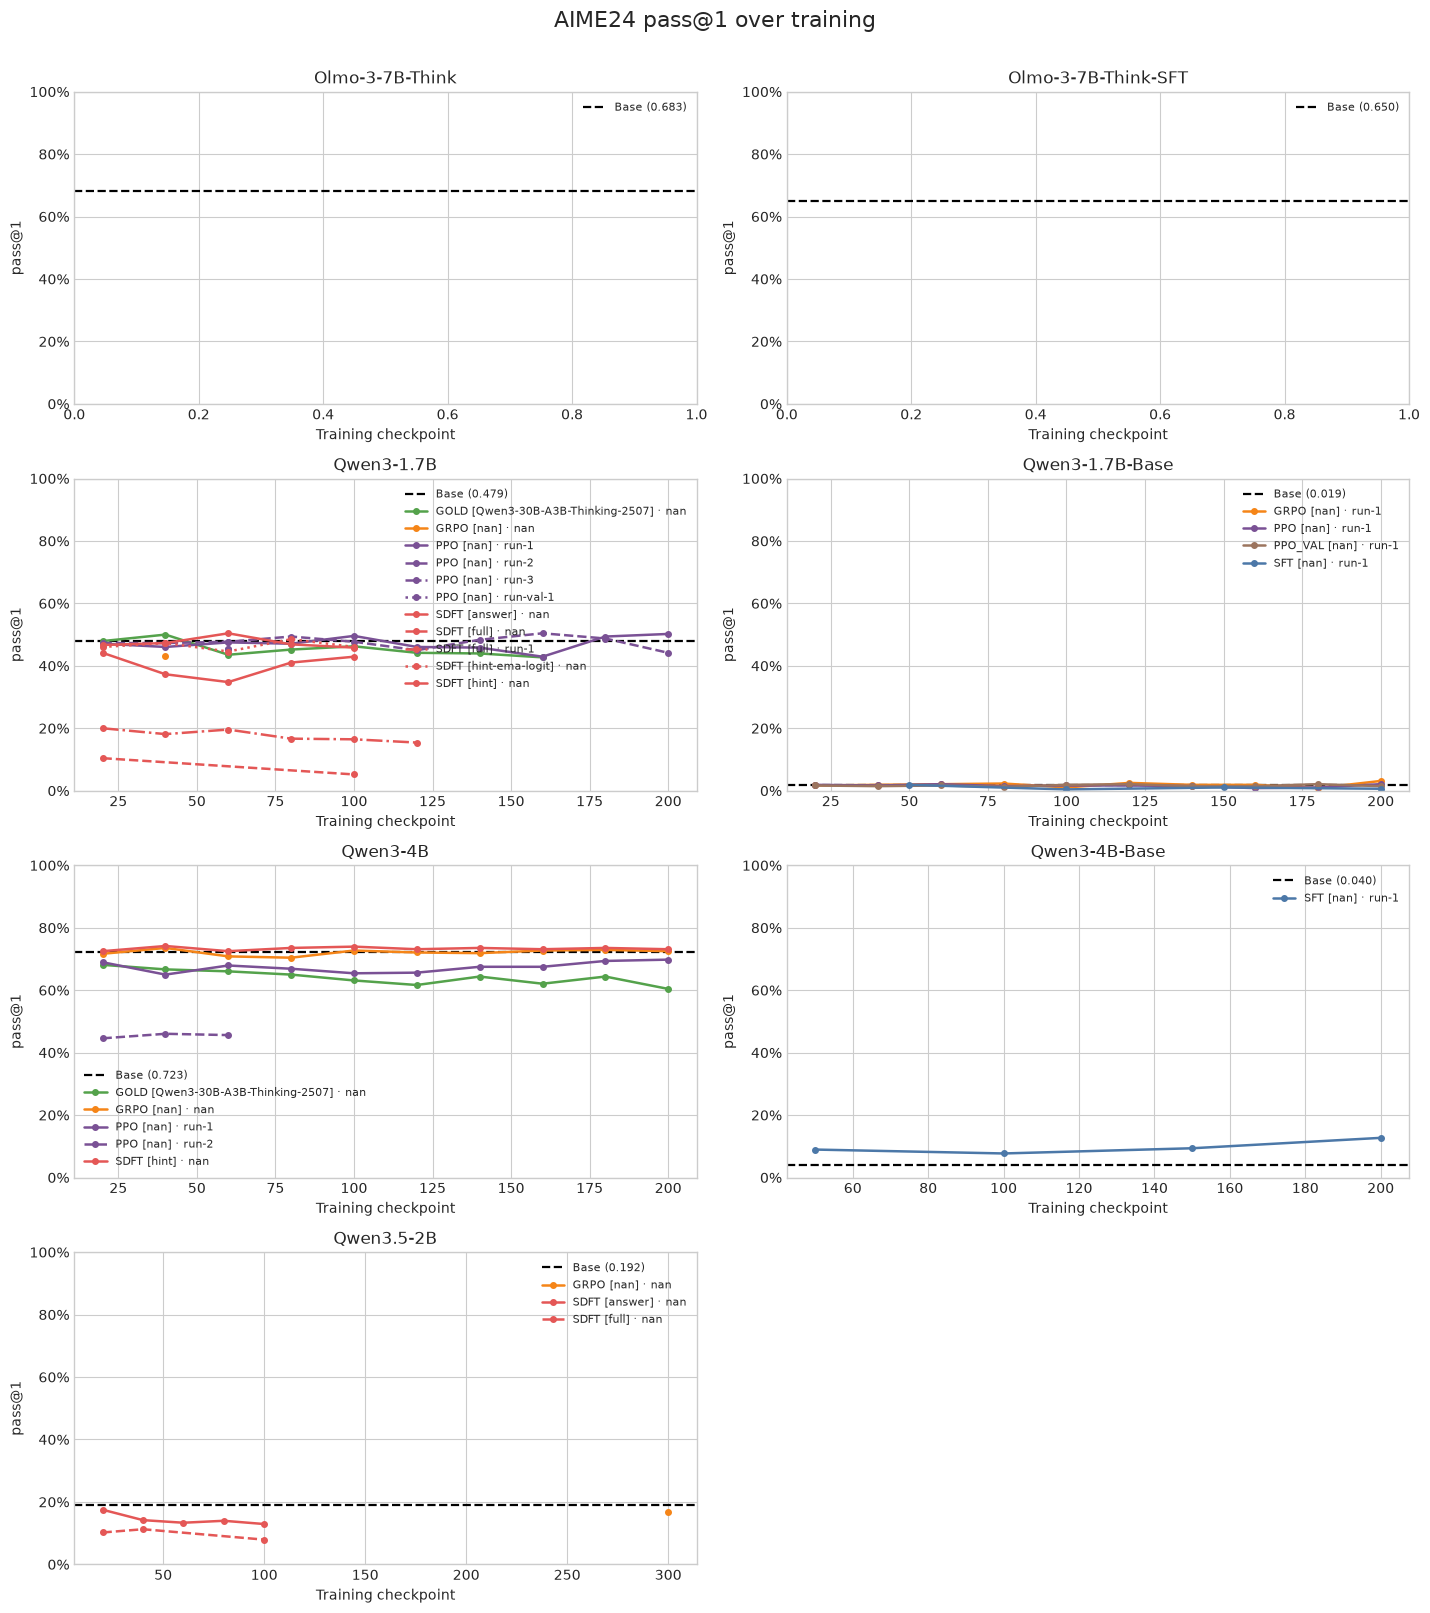

In [5]:
ALGO_COLORS = {
    "sft": "#4c78a8",
    "grpo": "#f58518",
    "gold": "#54a24b",
    "sdft": "#e45756",
    "ppo": "#7a5195",
    "ppo_val": "#9c755f",
    "ppo_pi": "#e377c2",
    "sdft_tt": "#79706e",
}
LINESTYLES = ["-", "--", "-.", ":"]


def plot_aime_curves(frame: pd.DataFrame, metric: str = "pass@1", columns: int = 2):
    models = sorted(frame["model"].unique())
    rows = math.ceil(len(models) / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(7.2 * columns, 4.0 * rows), squeeze=False)

    for ax, model in zip(axes.flat, models):
        model_frame = frame[frame["model"] == model]
        base = model_frame[model_frame["is_base"]]
        if not base.empty:
            value = base.iloc[-1][metric]
            ax.axhline(value, color="black", linewidth=1.6, linestyle="--", label=f"Base ({value:.3f})")

        trained = model_frame[~model_frame["is_base"]].copy()
        trained["series"] = trained.apply(method_label, axis=1)
        for index, (series, group) in enumerate(trained.groupby("series", sort=True)):
            algo = group.iloc[0]["algo"]
            same_algo_series = sorted(trained.loc[trained["algo"] == algo, "series"].unique())
            style_index = same_algo_series.index(series) % len(LINESTYLES)
            group = group.sort_values("checkpoint")
            ax.plot(
                group["checkpoint"], group[metric], marker="o", markersize=4,
                linewidth=1.8, linestyle=LINESTYLES[style_index],
                color=ALGO_COLORS.get(algo), label=series,
            )

        ax.set_title(model)
        ax.set_xlabel("Training checkpoint")
        ax.set_ylabel(metric)
        ax.set_ylim(0, 1)
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(fontsize=8, loc="best")

    for ax in axes.flat[len(models):]:
        ax.set_visible(False)
    fig.suptitle(f"AIME24 {metric} over training", fontsize=16, y=1.005)
    fig.tight_layout()
    return fig


plot_aime_curves(aime, "pass@1");

The table below is a compact model × algorithm/variant view of the same best-checkpoint selection. `AIME_BEST_K` controls both the per-model tables and this matrix; blanks mean an arm has not yet been evaluated for that model.


In [6]:
aime_best["algorithm_variant"] = aime_best.apply(
    lambda row: method_label(row, include_run=False), axis=1
)
best_matrix = aime_best.pivot(
    index="model", columns="algorithm_variant", values=AIME_BEST_METRIC
)
display(
    best_matrix.style
    .format("{:.3f}", na_rep="—")
    .background_gradient(cmap="Blues", vmin=0, vmax=1)
)

algorithm_variant,Base,GOLD [Qwen3-30B-A3B-Thinking-2507],GRPO [nan],PPO [nan],PPO_VAL [nan],SDFT [answer],SDFT [full],SDFT [hint-ema-logit],SDFT [hint],SFT [nan]
model,,,,,,,,,,
Olmo-3-7B-Think,0.683,—,—,—,—,—,—,—,—,—
Olmo-3-7B-Think-SFT,0.650,—,—,—,—,—,—,—,—,—
Qwen3-1.7B,0.479,0.500,0.431,0.504,—,0.442,0.200,0.485,0.504,—
Qwen3-1.7B-Base,0.019,—,0.031,0.021,0.021,—,—,—,—,0.019
Qwen3-4B,0.723,0.681,0.735,0.698,—,—,—,—,0.742,—
Qwen3-4B-Base,0.040,—,—,—,—,—,—,—,—,0.127
Qwen3.5-2B,0.192,—,0.167,—,—,0.175,0.113,—,—,—


## Privileged-information pass@k

These results measure how the same problem-solving model behaves when generation itself is conditioned on no PI, a hint, the answer, or the full solution. The raw pass@k values are shown directly; improvements relative to `none` can be added when deeper comparative analysis begins.


In [7]:
PASSK_PI_DIR = RESULTS / "passk_pi"
PI_ORDER = ["none", "hint", "answer", "full"]
PI_COLORS = {
    "none": "#9d9d9d",
    "hint": "#4c78a8",
    "answer": "#f58518",
    "full": "#54a24b",
}


def load_passk_pi() -> pd.DataFrame:
    rows = []
    for path in sorted(PASSK_PI_DIR.glob("*/passk_pi_summary.json")):
        summary = read_json(path)
        model = summary["model"].split("/")[-1]
        for pi_mode, metrics in summary["pass_at_k"].items():
            rows.append({
                "model": model,
                "model_id": summary["model"],
                "pi_mode": pi_mode,
                "n_problems": summary["n_problems"],
                "n_samples": summary["n_samples"],
                "max_tokens": summary["max_tokens"],
                "seed": summary["seed"],
                "source": str(path.relative_to(ROOT)),
                **metrics,
            })
    frame = pd.DataFrame(rows)
    if not frame.empty:
        frame["pi_mode"] = pd.Categorical(frame["pi_mode"], PI_ORDER, ordered=True)
        frame = frame.sort_values(["model", "pi_mode"]).reset_index(drop=True)
    return frame


passk_pi = load_passk_pi()
print(f"Loaded {len(passk_pi)} PI conditions across {passk_pi['model'].nunique()} models.")
display(
    passk_pi[["model", "pi_mode", "pass@1", "pass@8", "n_problems", "n_samples", "max_tokens", "seed"]]
    .style.format({"pass@1": "{:.3f}", "pass@8": "{:.3f}"})
    .background_gradient(subset=["pass@1", "pass@8"], cmap="Greens", vmin=0, vmax=1)
)

Loaded 16 PI conditions across 4 models.


,model,pi_mode,pass@1,pass@8,n_problems,n_samples,max_tokens,seed
0,Olmo-3-7B-Think,none,0.364,0.578,128,8,8192,42
1,Olmo-3-7B-Think,hint,0.519,0.781,128,8,8192,42
2,Olmo-3-7B-Think,answer,0.548,0.812,128,8,8192,42
3,Olmo-3-7B-Think,full,0.979,1.000,128,8,8192,42
4,Qwen3-1.7B,none,0.646,0.836,128,8,8192,42
5,Qwen3-1.7B,hint,0.675,0.898,128,8,8192,42
6,Qwen3-1.7B,answer,0.802,0.969,128,8,8192,42
7,Qwen3-1.7B,full,0.997,1.000,128,8,8192,42
8,Qwen3-4B,none,0.677,0.866,127,8,8192,42
9,Qwen3-4B,hint,0.723,0.882,127,8,8192,42


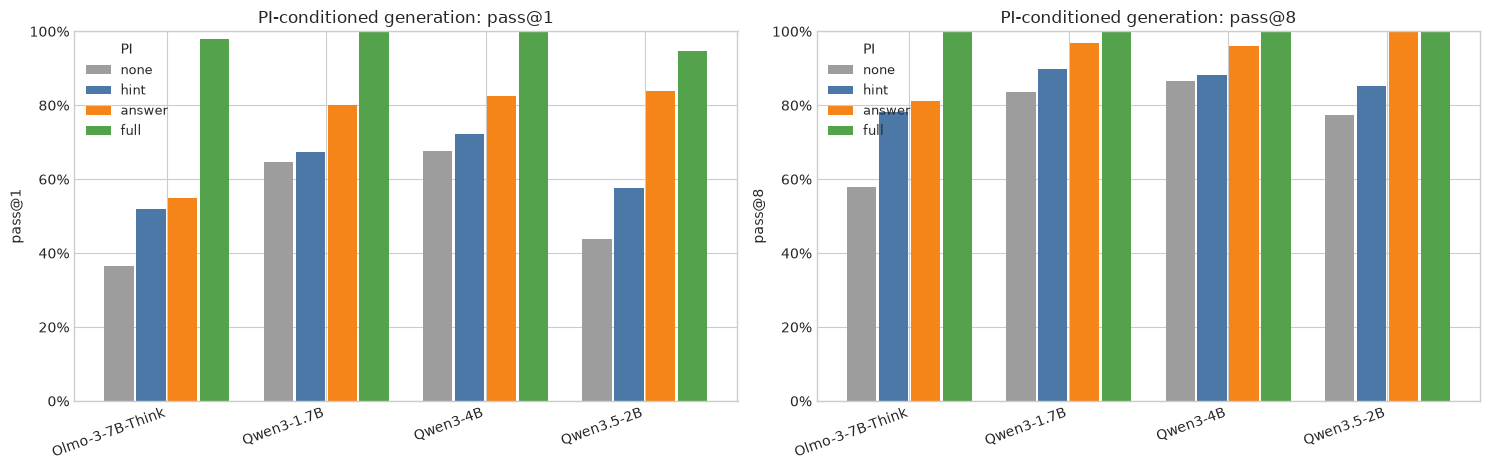

In [8]:
def grouped_bar(ax, frame: pd.DataFrame, value: str, title: str, percent: bool = False):
    models = sorted(frame["model"].unique())
    modes = [mode for mode in PI_ORDER if mode in set(frame["pi_mode"].astype(str))]
    x = np.arange(len(models), dtype=float)
    width = 0.8 / max(len(modes), 1)

    for index, mode in enumerate(modes):
        values = (
            frame[frame["pi_mode"].astype(str) == mode]
            .set_index("model")[value]
            .reindex(models)
        )
        offset = (index - (len(modes) - 1) / 2) * width
        ax.bar(x + offset, values, width=width * 0.92, label=mode, color=PI_COLORS[mode])

    ax.set_xticks(x, models, rotation=20, ha="right")
    ax.set_title(title)
    ax.set_ylabel(value)
    if percent:
        ax.set_ylim(0, 1)
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.legend(title="PI", fontsize=9)


fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
grouped_bar(axes[0], passk_pi, "pass@1", "PI-conditioned generation: pass@1", percent=True)
grouped_bar(axes[1], passk_pi, "pass@8", "PI-conditioned generation: pass@8", percent=True)
fig.tight_layout()

## Teacher behavior

Teacher-behavior summaries describe more than answer accuracy. The first dashboard keeps differently scaled quantities on separate axes: correctness, response length, truncation, and epistemic-marker density. This makes the behavioral shift under richer PI visible without combining incompatible units.


In [9]:
TEACHER_DIR = RESULTS / "teacher_behavior"


def load_teacher_behavior() -> tuple[pd.DataFrame, pd.DataFrame]:
    behavior_rows = []
    marker_rows = []
    for path in sorted(TEACHER_DIR.glob("*/teacher_behavior_summary.json")):
        summary = read_json(path)
        teacher = summary["teacher_model"].split("/")[-1]
        problem_model = summary["problem_model"].split("/")[-1]
        for pi_mode, metrics in summary["behavior"].items():
            common = {
                "teacher_model": teacher,
                "teacher_model_id": summary["teacher_model"],
                "problem_model": problem_model,
                "pi_mode": pi_mode,
                "n_problems": summary["n_problems"],
                "n_samples": summary["n_samples"],
                "max_tokens": summary["max_tokens"],
                "seed": summary["seed"],
                "source": str(path.relative_to(ROOT)),
            }
            behavior_rows.append({
                **common,
                **{key: value for key, value in metrics.items() if key != "e_by_marker_per_1k"},
            })
            for marker, value in metrics.get("e_by_marker_per_1k", {}).items():
                marker_rows.append({**common, "marker": marker, "per_1k_tokens": value})

    behavior = pd.DataFrame(behavior_rows)
    markers = pd.DataFrame(marker_rows)
    for frame in (behavior, markers):
        if not frame.empty:
            frame["pi_mode"] = pd.Categorical(frame["pi_mode"], PI_ORDER, ordered=True)
            frame.sort_values(["teacher_model", "pi_mode"], inplace=True)
            frame.reset_index(drop=True, inplace=True)
    return behavior, markers


teacher_behavior, teacher_markers = load_teacher_behavior()
teacher_columns = [
    "teacher_model", "problem_model", "pi_mode", "pass@1", "mean_tokens",
    "trunc_rate", "unclosed_rate", "e_per_1k_tokens", "n_completions",
]
display(
    teacher_behavior[teacher_columns]
    .style.format({
        "pass@1": "{:.3f}", "mean_tokens": "{:,.0f}", "trunc_rate": "{:.3f}",
        "unclosed_rate": "{:.3f}", "e_per_1k_tokens": "{:.2f}",
    })
)

,teacher_model,problem_model,pi_mode,pass@1,mean_tokens,trunc_rate,unclosed_rate,e_per_1k_tokens,n_completions
0,Qwen3-1.7B,Qwen3-1.7B,none,0.623,"6,232",0.379,0.330,11.64,512
1,Qwen3-1.7B,Qwen3-1.7B,hint,0.689,"5,746",0.289,0.225,10.92,512
2,Qwen3-1.7B,Qwen3-1.7B,answer,0.801,"5,269",0.264,0.236,11.64,512
3,Qwen3-1.7B,Qwen3-1.7B,full,0.998,880,0.000,0.986,1.68,512
4,Qwen3-30B-A3B-Thinking-2507,Qwen3-1.7B,none,0.678,"5,914",0.350,0.268,7.25,512


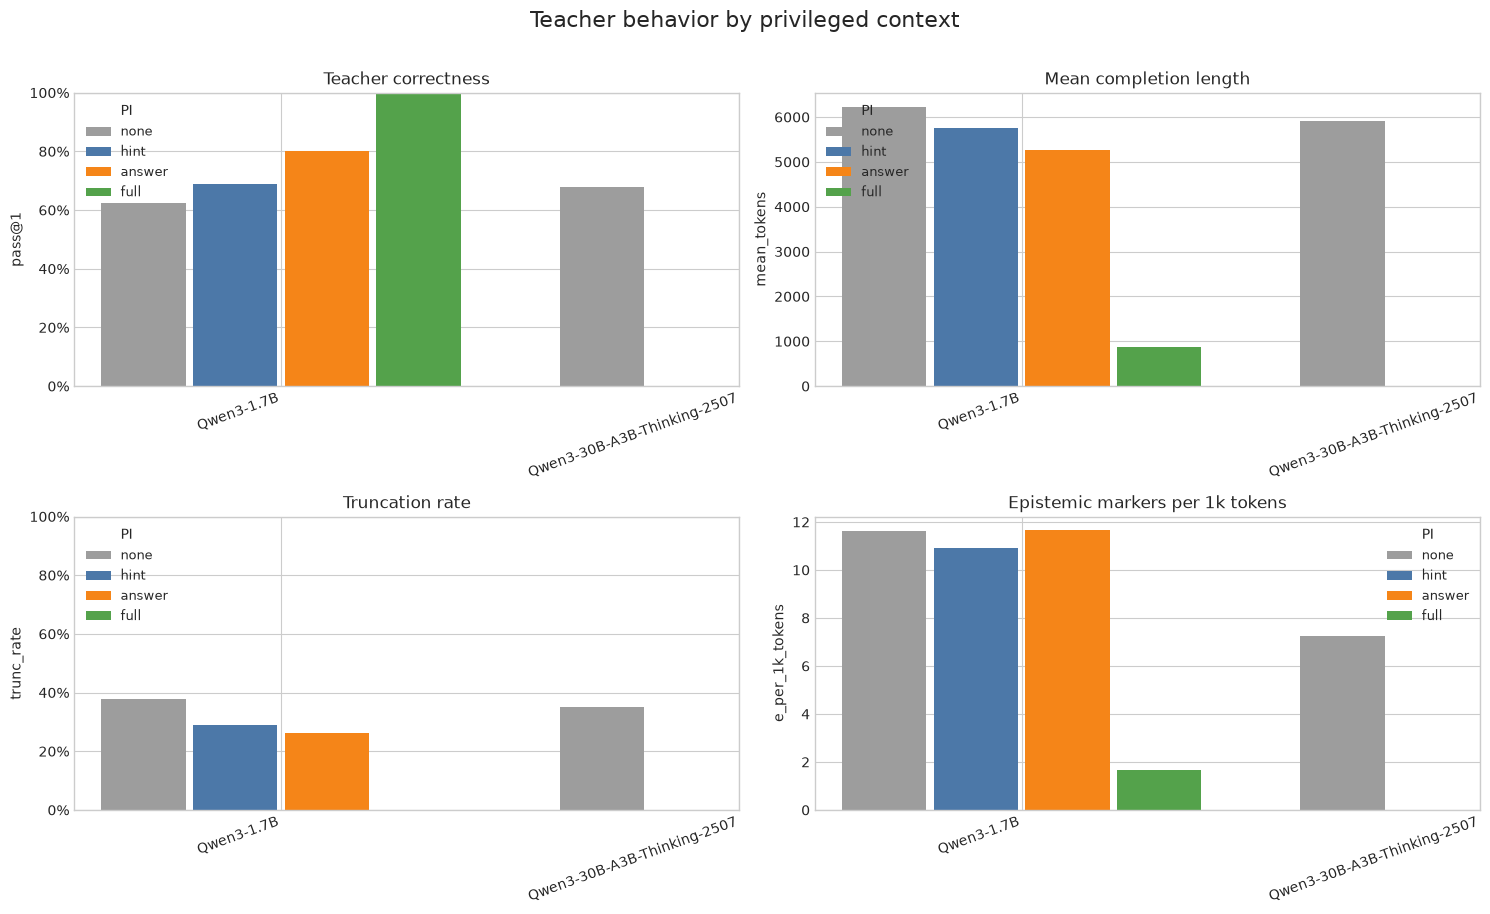

In [10]:
teacher_plot = teacher_behavior.rename(columns={"teacher_model": "model"})
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
grouped_bar(axes[0, 0], teacher_plot, "pass@1", "Teacher correctness", percent=True)
grouped_bar(axes[0, 1], teacher_plot, "mean_tokens", "Mean completion length")
grouped_bar(axes[1, 0], teacher_plot, "trunc_rate", "Truncation rate", percent=True)
grouped_bar(axes[1, 1], teacher_plot, "e_per_1k_tokens", "Epistemic markers per 1k tokens")
fig.suptitle("Teacher behavior by privileged context", fontsize=16, y=1.01)
fig.tight_layout()

## Result inventory and next additions

The inventory below makes missing result families explicit and provides a quick check after adding files. Natural next analysis layers are:

1. paired, per-problem uncertainty estimates from `results.json` rather than treating completions as independent;
2. aggregation across repeated training seeds, with mean and confidence intervals;
3. latest-versus-best checkpoint reporting and checkpoint-selection rules;
4. deltas from each exact base model and learning-curve summaries;
5. response-length, extraction-failure, and per-problem difficulty analysis; and
6. additional benchmark sections using the same tidy-table pattern.


In [11]:
inventory = pd.DataFrame([
    {
        "section": "aime24",
        "summary_files": len(aime),
        "models": aime["model"].nunique(),
        "conditions_or_arms": aime[["model", "algo", "variant", "run"]].drop_duplicates().shape[0],
    },
    {
        "section": "passk_pi",
        "summary_files": passk_pi["source"].nunique(),
        "models": passk_pi["model"].nunique(),
        "conditions_or_arms": len(passk_pi),
    },
    {
        "section": "teacher_behavior",
        "summary_files": teacher_behavior["source"].nunique(),
        "models": teacher_behavior["teacher_model"].nunique(),
        "conditions_or_arms": len(teacher_behavior),
    },
])
display(inventory)

,section,summary_files,models,conditions_or_arms
0,aime24,151,7,31
1,passk_pi,4,4,16
2,teacher_behavior,2,2,5
